# 1: Project Header (Markdown)

# 🚦 US Accidents Severity Prediction — Version 4 (Production)
### Step-by-Step Pipeline: Training + Dashboard Comparison

**Goal:** Predict high-severity accidents (Severity 3-4) using pre-incident data.
**Improvements:** - **No Leakage:** Removed features like `Distance(mi)` and `Duration`.
- **Optimization:** Balanced recall and precision using Youden's J-statistic.
- **Dashboard:** Automatic comparison with previous model attempts.

# 2: Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report, f1_score

from catboost import CatBoostClassifier

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 3: Data Loading & Feature Selection

In [2]:
# Load the Gold Layer Dataset
df = pd.read_csv(r"F:\Depi Project\Final\Gold_Layer\US_Accidents_Gold_Modeling.csv")

# 1. Define Binary Target (3-4 = High Risk)
df['Severity_Binary'] = (df['Severity'] >= 3).astype(int)

# 2. Define Strictly Pre-Incident Features
CAT_FEATURES = [
    'Day_of_Week', 'Month', 'Time_of_Day_Encoded', 'Timezone_Encoded',
    'Sunrise_Sunset_Encoded', 'Weather_Condition_Encoded', 'Wind_Direction_Encoded'
]

NUM_FEATURES = [
    'Temperature_F', 'Humidity_pct', 'Pressure_in', 'Visibility_mi',
    'Wind_Speed_mph', 'Precipitation_in', 'Hour', 'Is_Weekend', 
    'Is_Rush_Hour', 'Road_Features_Count', 'Has_Traffic_Signal', 
    'Has_Crossing', 'Has_Junction'
]

FEATURES = CAT_FEATURES + NUM_FEATURES
X, y = df[FEATURES], df['Severity_Binary']

# 4: Train-Validation-Test Split

In [3]:
# Stratified Split (70% Train, 15% Val, 15% Test)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)

# Convert categorical columns to strings for CatBoost
for col in CAT_FEATURES:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_valid[col] = X_valid[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

# 5: CatBoost Model Training

In [4]:
# Handling imbalance automatically
spw = (y_train == 0).sum() / (y_train == 1).sum()

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    scale_pos_weight=spw,
    random_seed=42,
    verbose=100,
    cat_features=CAT_FEATURES
)

model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

0:	test: 0.6915309	best: 0.6915309 (0)	total: 349ms	remaining: 5m 48s
100:	test: 0.7260666	best: 0.7260666 (100)	total: 17s	remaining: 2m 31s
200:	test: 0.7325419	best: 0.7325419 (200)	total: 34.5s	remaining: 2m 17s
300:	test: 0.7359905	best: 0.7359905 (300)	total: 52.4s	remaining: 2m 1s
400:	test: 0.7382535	best: 0.7382535 (400)	total: 1m 10s	remaining: 1m 44s
500:	test: 0.7408116	best: 0.7408116 (500)	total: 1m 26s	remaining: 1m 26s
600:	test: 0.7429971	best: 0.7429971 (600)	total: 1m 43s	remaining: 1m 8s
700:	test: 0.7447178	best: 0.7447178 (700)	total: 2m	remaining: 51.2s
800:	test: 0.7457485	best: 0.7457485 (800)	total: 2m 17s	remaining: 34s
900:	test: 0.7468007	best: 0.7468007 (900)	total: 2m 33s	remaining: 16.9s
999:	test: 0.7475804	best: 0.7475804 (999)	total: 2m 50s	remaining: 0us

bestTest = 0.7475803951
bestIteration = 999



CatBoostClassifier(cat_features=['Day_of_Week', 'Month', 'Time_of_Day_Encoded', 'Timezone_Encoded', 'Sunrise_Sunset_Encoded', 'Weather_Condition_Encoded', 'Wind_Direction_Encoded'], depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.03, random_seed=42, scale_pos_weight=np.float64(4.123778310996664), verbose=100)

# 6: Metric Calculation & Thresholding

In [5]:
# 1. Get probabilities
valid_probs = model.predict_proba(X_valid)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# 2. Optimize Threshold (Find best balance)
fpr, tpr, thresholds = roc_curve(y_valid, valid_probs)
best_threshold = thresholds[np.argmax(tpr - fpr)]

# 3. Final Predictions & Definitive Metrics
test_preds = (test_probs >= best_threshold).astype(int)
auc_score = roc_auc_score(y_test, test_probs)
acc_score = accuracy_score(y_test, test_preds)

print(f"✅ Training Complete.")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Final ROC-AUC: {auc_score:.4f}")
print(f"Final Accuracy: {acc_score:.4f}")

✅ Training Complete.
Optimal Threshold: 0.5034
Final ROC-AUC: 0.7460
Final Accuracy: 0.6976


# 7: Feature Importance Plot

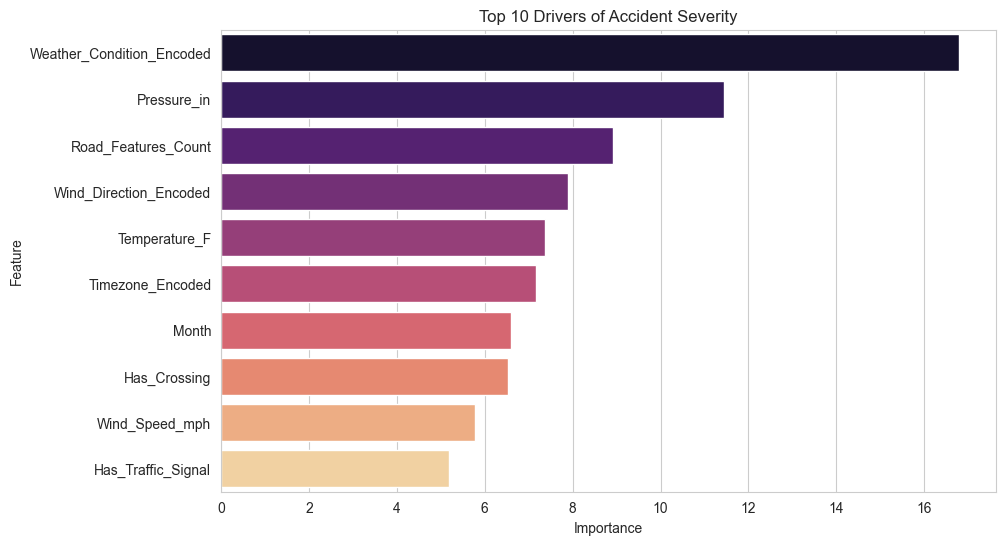

In [6]:
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.get_feature_importance()
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Drivers of Accident Severity')
plt.show()

# 8: Dashboard Comparison (Final Summary)

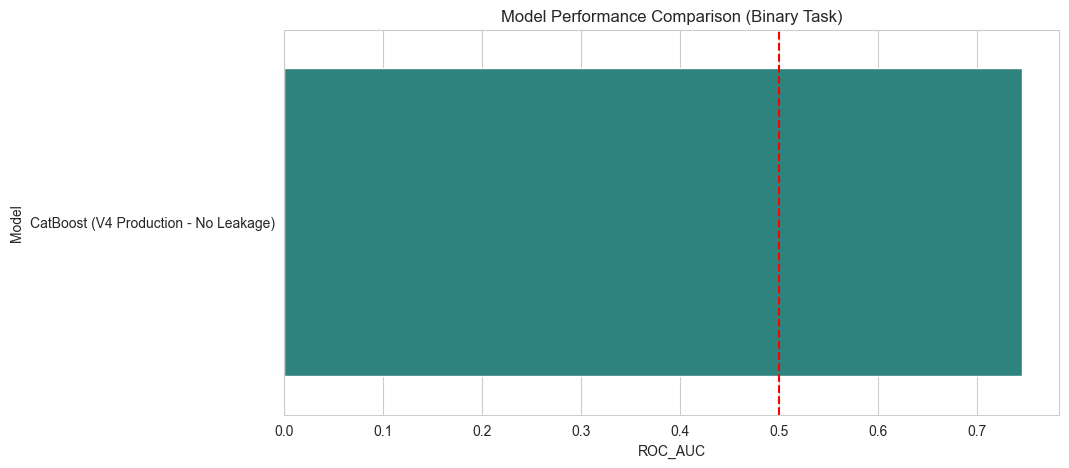

In [7]:
# Load your previous summary csv
summary_path = r"F:\Depi Project\Final\Gold_Layer\ML_Results_Summary.csv"

try:
    results_df = pd.read_csv(summary_path)
except FileNotFoundError:
    results_df = pd.DataFrame(columns=['Task', 'Model', 'Accuracy', 'ROC_AUC'])

# Add new V4 result
new_row = pd.DataFrame([{
    'Task': 'Binary',
    'Model': 'CatBoost (V4 Production - No Leakage)',
    'Accuracy': acc_score,
    'ROC_AUC': auc_score
}])

# Merge and Save
final_dashboard = pd.concat([results_df, new_row], ignore_index=True)
final_dashboard.to_csv("Final_Dashboard_Report.csv", index=False)

# Visualize Comparison for the Dashboard
plt.figure(figsize=(10, 5))
sns.barplot(data=final_dashboard[final_dashboard['Task']=='Binary'], x='ROC_AUC', y='Model', palette='viridis')
plt.title('Model Performance Comparison (Binary Task)')
plt.axvline(0.5, color='red', linestyle='--', label='Random Chance')
plt.show()

# 9: Export for Prediction Service

In [8]:
import os
if not os.path.exists('Models'): os.makedirs('Models')

joblib.dump(model, "Models/catboost_final_v4.pkl")
joblib.dump(FEATURES, "Models/features_v4.pkl")
joblib.dump(best_threshold, "Models/threshold_v4.pkl")

print("✅ Artifacts saved to /Models folder.")

✅ Artifacts saved to /Models folder.


# 10: FINAL STEP: PREPARE DATA FOR POWER BI DASHBOARD

In [9]:

old_results_path = r"F:\Depi Project\Final\Gold_Layer\ML_Results_Summary.csv"

# 2. Load old results or create a new dataframe if file doesn't exist
try:
    combined_summary = pd.read_csv(old_results_path)
    print("✅ Old results loaded successfully.")
except FileNotFoundError:
    combined_summary = pd.DataFrame(columns=['Task', 'Model', 'Accuracy', 'ROC_AUC'])
    print("⚠️ Old results file not found. Creating new summary.")

# 3. Add your new "V4 Production" results (from the variables defined in Cell 6)
new_entry = pd.DataFrame([{
    'Task': 'Binary',
    'Model': 'CatBoost (V4 Production - No Leakage)',
    'Accuracy': acc_score, # Defined in evaluation cell
    'ROC_AUC': auc_score   # Defined in evaluation cell
}])

# 4. Merge them together
combined_summary = pd.concat([combined_summary, new_entry], ignore_index=True)

# 5. Save the final file for Power BI
power_bi_path = r"F:\Depi Project\Final\Gold_Layer\Final_Dashboard_Summary.csv"
combined_summary.to_csv(power_bi_path, index=False)

print(f"🚀 SUCCESS! File saved for Power BI at: {power_bi_path}")
print(combined_summary.tail(5))

⚠️ Old results file not found. Creating new summary.
🚀 SUCCESS! File saved for Power BI at: F:\Depi Project\Final\Gold_Layer\Final_Dashboard_Summary.csv
     Task                                  Model Accuracy   ROC_AUC
0  Binary  CatBoost (V4 Production - No Leakage)  0.69764  0.745981
